# CRACO-63 - with data generator


In [1]:
import numpy as np
from pylab import *
from craco.cardcap import CardcapFile
from astropy.io import fits

%matplotlib notebook

Enable test generator
Have chipscope on baseline select.

In [2]:
!ls data/craco63/testgen_chipscopeblsel/

cap_s32v2.pcap	header_3.bin		    testgen-s32v4_b01_c01.fits
cap_s64v2.pcap	header_5.bin		    testgen-s32v5_b01_c01.fits
cap_s64v3.pcap	header_fpga1.txt	    testgen-s32v6_b01_c01.fits
cap_s64v4.pcap	header_fpga3.txt	    testgen-s32v7_b01_c01.fits
cap_s64v5.pcap	header_fpga5.txt	    testgen-s32v8_b01_c01.fits
cap_s64v6.pcap	testgen-s32_b01_c01.fits    testgen-s64-ps-v9_b01_c01.fits
cap_s64v7.pcap	testgen-s32v2_b01_c01.fits  testgen-s64-ps-v9.fits
header_1.bin	testgen-s32v3_b01_c01.fits  testgen-s64v2_b01_c01.fits


In [3]:
ccf = [CardcapFile(f'data/craco63/testgen_chipscopeblsel/testgen-s32v8_b01_c01.fits') for spi in (32,)]

nfpga=1
nbeam=36
nchan=4
nt = 2048//ccf[0].mainhdr['SAMPINT']
chan = 0
pol = 1
blocksz = nfpga*nchan*nt

In [4]:
pkts = [cc.load_packets() for cc in ccf]

In [5]:
p0 = pkts[0]
p0 = p0[p0['fpga_id'] == 2]
blidx = 0

In [6]:
dunique = np.unique(p0['data'][:,:,blidx,0,0])
dunique

array([151, 282, 301, 351], dtype=int16)

In [7]:
9701/dunique 

array([64.24503311, 34.40070922, 32.22923588, 27.63817664])

In [8]:
p0['data'][0,0,0,0,0]

151

In [9]:
hex(p0['data'][0,0,0,0,0])

'0x97'

<IPython.core.display.Javascript object>


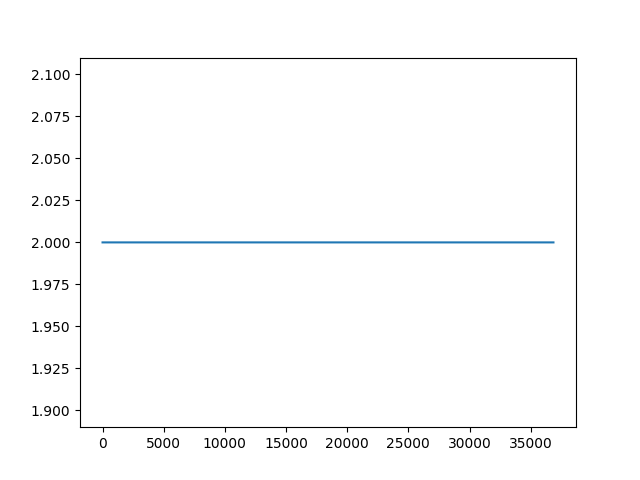

In [10]:
figure()
plot(p0['fpga_id'])

<IPython.core.display.Javascript object>


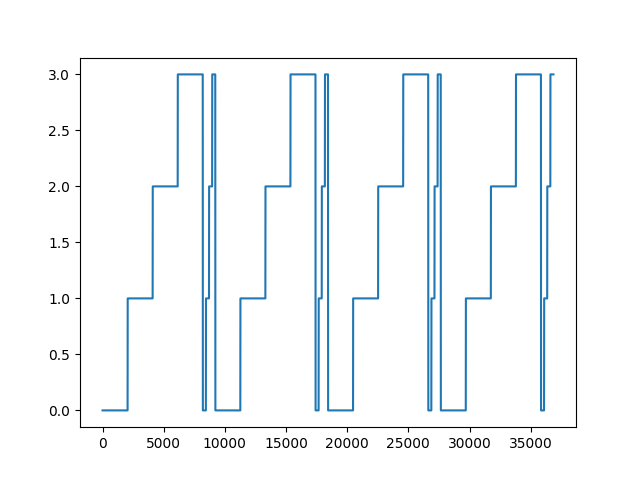

In [11]:
figure()
plot(p0['channel_number'])

<IPython.core.display.Javascript object>


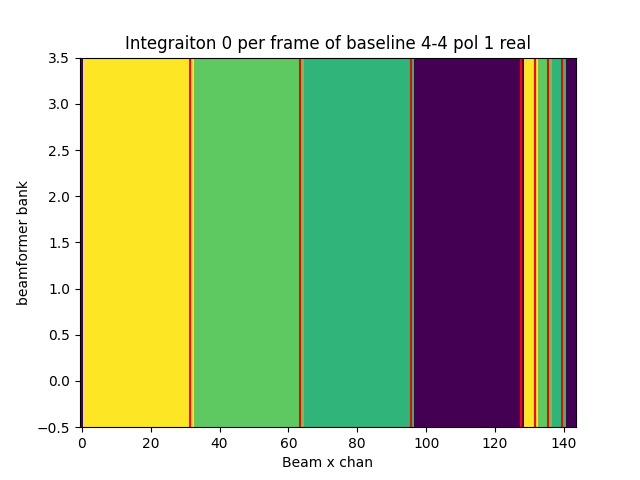

Text(0.5, 1.0, 'Integraiton 0 per frame of baseline 4-4 pol 1 real')

In [12]:
def axvbracket(t, *args, **kwargs):
    #axvline(t+0.5, c='r', *args, **kwargs)
    axvline(t-0.5, c='r',*args, **kwargs)
    #pass

    

figure()
shift = 0
x2 = np.roll(p0['data'][::,0,blidx,0,0], shift)[0::64].reshape(-1,36*4)
imshow(x2[:,:], aspect='auto', origin='lower')
axvbracket(0)
axvbracket(32)
axvbracket(32*2)
axvbracket(32*3)
axvbracket(32*4)
axvbracket(32*4)
axvbracket(33*4)
axvbracket(34*4)
axvbracket(35*4)
xlabel('Beam x chan')
ylabel('beamformer bank')
title('Integraiton 0 per frame of baseline 4-4 pol 1 real')

In [13]:
pa = pkts[0]

In [14]:
fpa = [pa[pa['fpga_id'] == f] for f in (0,2,4)]


In [15]:
first_frameid = np.array([f['frame_id'][0] for f in fpa])
first_frameid

array([1501184, 1501184, 1501184], dtype=uint64)

In [16]:
wireshark_fid = 0x6bf840
wireshark_fid

7075904

In [17]:
first_frameid /1e6

array([1.501184, 1.501184, 1.501184])

In [18]:
johnfid = 0x68800
johnfid

428032

In [19]:
first_frameid / johnfid

array([3.50717703, 3.50717703, 3.50717703])

In [20]:
list(map( hex, first_frameid))

['0x16e800', '0x16e800', '0x16e800']

In [21]:
(first_frameid[0] - johnfid)/2048

524.0

In [22]:
(first_frameid[0] - johnfid)*1e-6*27/32


0.9054719999999999

In [23]:
first_sampleno = [f['sample_number'][0] for f in fpa]
first_sampleno

[0, 0, 0]

In [24]:
0x195b000

26587136

<IPython.core.display.Javascript object>


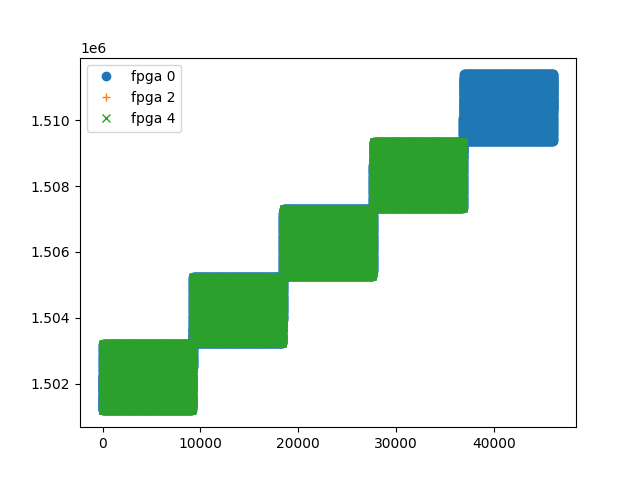

In [25]:
figure()
plot(fpa[0]['frame_id'],'o', label='fpga 0')
plot(fpa[1]['frame_id'],'+',label='fpga 2')
plot(fpa[2]['frame_id'],'x',label='fpga 4')
legend()

In [26]:
0x25e5

9701

In [27]:
hex(p0['data'][0,0,0,0,0])

'0x97'

In [28]:
hex(p0['data'][0,0,0,1,0])

'0xdc'

In [29]:
hex(351)

'0x15f'

In [30]:
x = np.arange(16, dtype=np.int16).reshape(4,4)*4000
x

array([[     0,   4000,   8000,  12000],
       [ 16000,  20000,  24000,  28000],
       [ 32000, -29536, -25536, -21536],
       [-17536, -13536,  -9536,  -5536]], dtype=int16)

In [31]:
x.mean(axis=1, dtype=np.float32).dtype

dtype('float32')

In [32]:
x.mean(axis=1, dtype=np.float32)

array([  6000.,  22000., -11152., -11536.], dtype=float32)

In [33]:
x.mean(axis=1, dtype=np.float32).astype(np.int16)

array([  6000,  22000, -11152, -11536], dtype=int16)

In [34]:
p0['data'].shape

(36864, 1, 465, 2, 2)

In [35]:
p0.shape

(36864,)

In [36]:
p0['data'].shape

(36864, 1, 465, 2, 2)

<IPython.core.display.Javascript object>


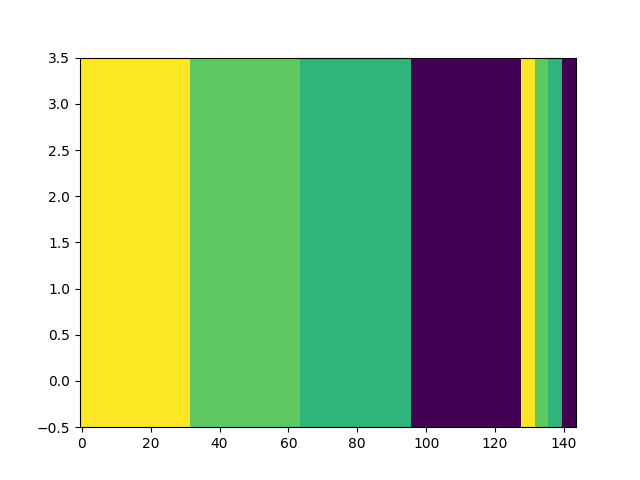

In [41]:
figure()
shift = -1
x2 = np.roll(p0['data'][::,0,blidx,0,0], shift)[0::64].reshape(-1,36*4)
x2 = np.roll(p0['data'], shift, axis=0)[::64, 0, blidx, 0,0].reshape(-1, 36*4)
imshow(x2[:,:], aspect='auto', origin='lower')